In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# k-armed Bandit Problem

In [4]:
class Bandit:
    def __init__(self, policy_args, bandit_args):
        self.n_arms = bandit_args.get('n_arms', 10)
        self.q_true_var = bandit_args.get('q_true_var', 1)
        self.reward_var = bandit_args.get('reward_var', 1)
        self.is_non_stationary = bandit_args.get('is_non_stationary', False)
        self.q_true = None
        self.best_action_idx = None
        self.q_estimate = None
        self.action_count = None
        self.policy_args = policy_args
        self._reset()
        self._generate_true_action_values()

    def _reset(self):
        self.q_true = np.zeros(self.n_arms)  # True action values, initially set to zero
        self.q_estimate = np.zeros(self.n_arms)  # Reset estimates
        self.action_count = np.zeros(self.n_arms)  # Reset action counts

    def _generate_true_action_values(self):
        self.q_true += np.random.normal(0, self.q_true_var, self.n_arms)  # Sample true action values from a normal distribution
        self.best_action_idx = np.argmax(self.q_true)  # Update best action index based on new true values
    
    def _reward(self, action):
        return np.random.normal(self.q_true[action], self.reward_var)  # Reward with noise
    
    def _take_action(self, action):
        reward = self._reward(action)
        self.action_count[action] += 1
        # Update estimate with new reward
        step_size = self.policy_args.get('step_size', None)
        step_size = step_size if step_size is not None else 1 / self.action_count[action]  # Use provided step size or default to 1/n
        self.q_estimate[action] += step_size * (reward - self.q_estimate[action])
        return reward
    
    def policy(self):
        policy_type = self.policy_args.get('type', 'greedy')
        noise = np.random.random(self.n_arms) * 1e-5  # Small noise to break ties
        
        if policy_type == 'greedy':
            return np.argmax(self.q_estimate + noise)  # Greedy action with tie-breaking
        
        elif policy_type == 'epsilon_greedy':
            epsilon = self.policy_args.get('epsilon', 0.1)
            if np.random.rand() < epsilon:
                return np.random.randint(self.n_arms)  # Explore
            else:
                return np.argmax(self.q_estimate + noise)  # Exploit
        else:
            raise ValueError(f"Unknown policy type: {policy_type}")
    
    def run(self, n_steps):
        rewards = np.zeros(n_steps)
        best_action_count = np.zeros(n_steps)
        mse_history = pd.DataFrame(np.zeros((n_steps, self.n_arms)))  # To track MSE of estimates over time

        for step in range(n_steps):
            if self.is_non_stationary:
                self._generate_true_action_values()  # Regenerate true action values at each step
            
            action = self.policy()
            rewards[step] = self._take_action(action)

            if action == self.best_action_idx:
                best_action_count[step] = 1
            mse_history.iloc[step] = (self.q_estimate - self.q_true) ** 2  # MSE of estimates
        best_action_perct = np.cumsum(best_action_count) / (np.arange(n_steps) + 1)  # Cumulative average of optimal action count
        
        return {
            'rewards': rewards,
            'best_action_percentage': best_action_perct,
            'mse_history': mse_history,
            'best_action_idx': self.best_action_idx
        }

In [81]:
bandit_params = {
    'n_arms': 10,
    'q_true_var': 1,
    'reward_var': 1
}

In [ ]:
n_steps = 1000
n_iterations = 2000
policies_args_map = {
    'greedy': {'type': 'greedy'},
    'epsilon_0.1': {'type': 'epsilon_greedy', 'epsilon': 0.1},
    'epsilon_0.01': {'type': 'epsilon_greedy', 'epsilon': 0.01}
}

rewards_map = {policy: pd.DataFrame(np.zeros((n_iterations, n_steps))) for policy in policies_args_map}
best_action_percentages_map = {policy: pd.DataFrame(np.zeros((n_iterations, n_steps))) for policy in policies_args_map}
best_action_mse_map = {policy: pd.DataFrame(np.zeros((n_iterations, n_steps))) for policy in policies_args_map}
alt_action_mse_map = {policy: pd.DataFrame(np.zeros((n_iterations, n_steps))) for policy in policies_args_map}

for i in range(n_iterations):
    for policy in policies_args_map:
        bandit = Bandit(policy_args=policies_args_map[policy], bandit_args=bandit_params)

        tmp = bandit.run(n_steps)
        rewards_map[policy].iloc[i] = tmp['rewards']
        best_action_percentages_map[policy].iloc[i] = tmp['best_action_percentage']
        best_action_mse_map[policy].iloc[i] = tmp['mse_history'][tmp['best_action_idx']]
        alt_action_mse_map[policy].iloc[i] = tmp['mse_history'].drop(columns=[tmp['best_action_idx']]).mean(axis=1)

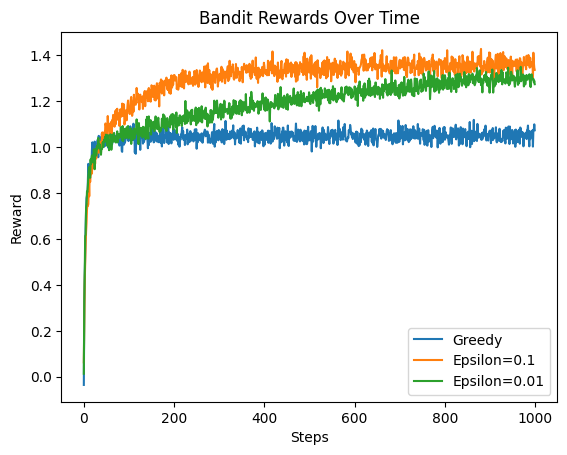

In [76]:
plt.plot(rewards_map['greedy'].mean(), label='Greedy')
plt.plot(rewards_map['epsilon_0.1'].mean(), label='Epsilon=0.1')
plt.plot(rewards_map['epsilon_0.01'].mean(), label='Epsilon=0.01')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.title('Bandit Rewards Over Time')
plt.legend()
plt.show()

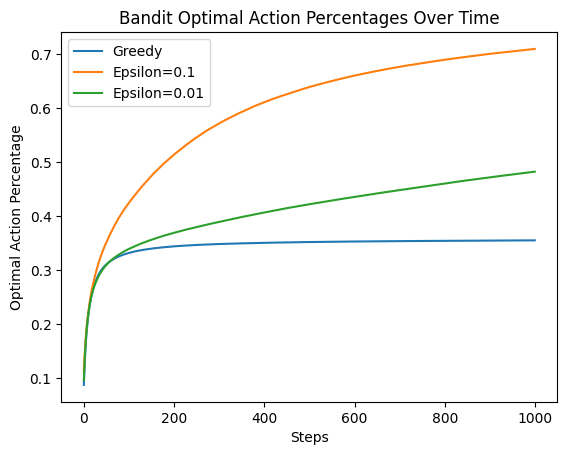

In [77]:
plt.plot(best_action_percentages_map['greedy'].mean(), label='Greedy')
plt.plot(best_action_percentages_map['epsilon_0.1'].mean(), label='Epsilon=0.1')
plt.plot(best_action_percentages_map['epsilon_0.01'].mean(), label='Epsilon=0.01')
plt.xlabel('Steps')
plt.ylabel('Optimal Action Percentage')
plt.title('Bandit Optimal Action Percentages Over Time')
plt.legend()
plt.show()

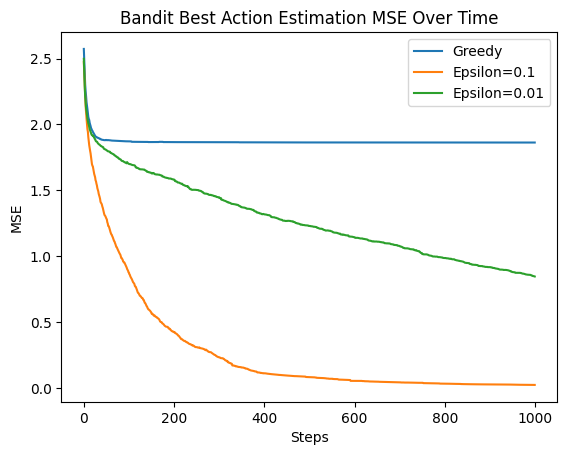

In [78]:
plt.plot(best_action_mse_map['greedy'].mean(), label='Greedy')
plt.plot(best_action_mse_map['epsilon_0.1'].mean(), label='Epsilon=0.1')
plt.plot(best_action_mse_map['epsilon_0.01'].mean(), label='Epsilon=0.01')
plt.xlabel('Steps')
plt.ylabel('MSE')
plt.title('Bandit Best Action Estimation MSE Over Time')
plt.legend()
plt.show()

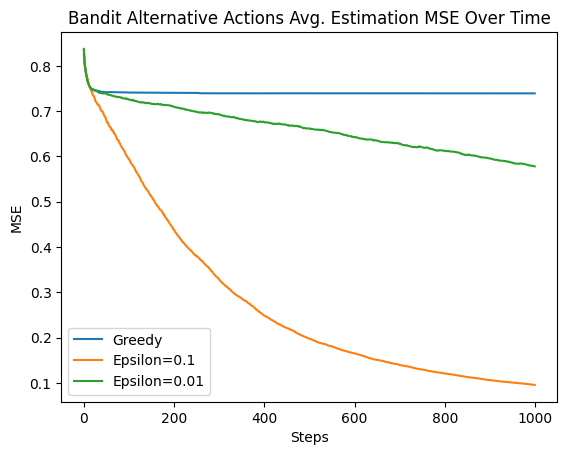

In [79]:
plt.plot(alt_action_mse_map['greedy'].mean(), label='Greedy')
plt.plot(alt_action_mse_map['epsilon_0.1'].mean(), label='Epsilon=0.1')
plt.plot(alt_action_mse_map['epsilon_0.01'].mean(), label='Epsilon=0.01')
plt.xlabel('Steps')
plt.ylabel('MSE')
plt.title('Bandit Alternative Actions Avg. Estimation MSE Over Time')
plt.legend()
plt.show()

# Non Stationary k-armed Bandit Problem

In [5]:
bandit_params = {
    'n_arms': 10,
    'q_true_var': 0.01,
    'reward_var': 1,
    'is_non_stationary': True
}

policy_params = {
    'type': 'epsilon_greedy', 
    'epsilon': 0.1
}

In [10]:
n_steps = 10000
n_iterations = 200
comparison_list = ['shrinking_steps', 'constant_steps']

rewards_map = {comp: pd.DataFrame(np.zeros((n_iterations, n_steps))) for comp in comparison_list}
best_action_percentages_map = {comp: pd.DataFrame(np.zeros((n_iterations, n_steps))) for comp in comparison_list}
mse_map = {comp: pd.DataFrame(np.zeros((n_iterations, n_steps))) for comp in comparison_list}

for i in range(n_iterations):
    bandit_shrinking_steps = Bandit(policy_args=policy_params, bandit_args=bandit_params)
    bandit_constant_steps = Bandit(policy_args={**policy_params, 'step_size': 0.1}, bandit_args=bandit_params)

    tmp = bandit_shrinking_steps.run(n_steps)
    rewards_map['shrinking_steps'].iloc[i] = tmp['rewards']
    best_action_percentages_map['shrinking_steps'].iloc[i] = tmp['best_action_percentage']
    mse_map['shrinking_steps'].iloc[i] = tmp['mse_history'].mean(axis=1)

    tmp = bandit_constant_steps.run(n_steps)
    rewards_map['constant_steps'].iloc[i] = tmp['rewards']
    best_action_percentages_map['constant_steps'].iloc[i] = tmp['best_action_percentage']
    mse_map['constant_steps'].iloc[i] = tmp['mse_history'].mean(axis=1)

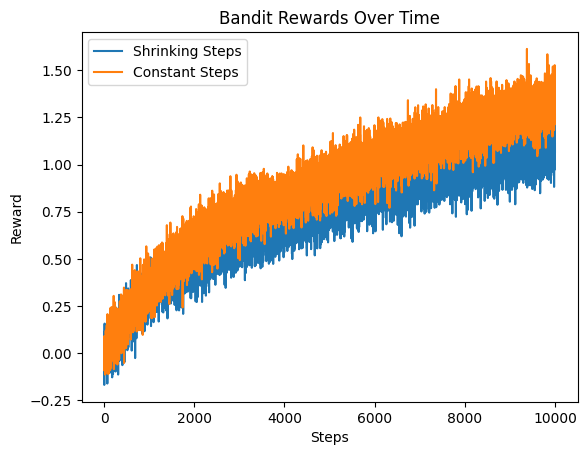

In [11]:
plt.plot(rewards_map['shrinking_steps'].mean(), label='Shrinking Steps')
plt.plot(rewards_map['constant_steps'].mean(), label='Constant Steps')
plt.xlabel('Steps')
plt.ylabel('Reward')
plt.title('Bandit Rewards Over Time')
plt.legend()
plt.show()

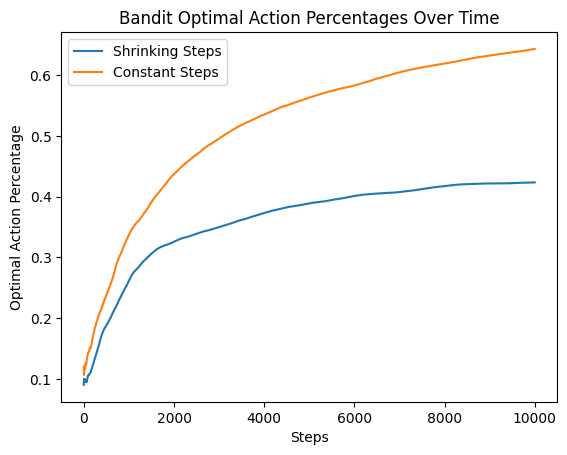

In [12]:
plt.plot(best_action_percentages_map['shrinking_steps'].mean(), label='Shrinking Steps')
plt.plot(best_action_percentages_map['constant_steps'].mean(), label='Constant Steps')
plt.xlabel('Steps')
plt.ylabel('Optimal Action Percentage')
plt.title('Bandit Optimal Action Percentages Over Time')
plt.legend()
plt.show()

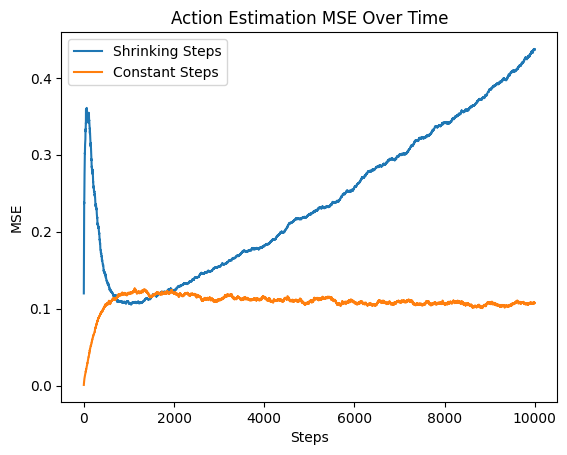

In [13]:
plt.plot(mse_map['shrinking_steps'].mean(), label='Shrinking Steps')
plt.plot(mse_map['constant_steps'].mean(), label='Constant Steps')
plt.xlabel('Steps')
plt.ylabel('MSE')
plt.title('Action Estimation MSE Over Time')
plt.legend()
plt.show()